In [1]:
!pip install nltk
!pip install beautifulsoup4 requests
!pip install --upgrade pip
!pip install datasets spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
import requests
from bs4 import BeautifulSoup
url = "https://quotes.toscrape.com/"

response = requests.get(url)

print(response.status_code)
soup = BeautifulSoup(response.text, "html.parser")

text = soup.get_text(separator=" ", strip=True)

print(text)

200
Quotes to Scrape Quotes to Scrape Login “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.” by Albert Einstein (about) Tags: change deep-thoughts thinking world “It is our choices, Harry, that show what we truly are, far more than our abilities.” by J.K. Rowling (about) Tags: abilities choices “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.” by Albert Einstein (about) Tags: inspirational life live miracle miracles “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.” by Jane Austen (about) Tags: aliteracy books classic humor “Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.” by Marilyn Monroe (about) Tags: be-yourself inspirational “Try not to become a man of success. Rather become a man of value.” by Albert Einstein (about) Ta

In [3]:
import spacy
nlp = spacy.load("en_core_web_sm")

doc = nlp(text)

for ent in doc.ents:
    print(ent.text, ent.label_)

Scrape Quotes ORG
Albert Einstein PERSON
Harry PERSON
J.K. Rowling PERSON
only two CARDINAL
One CARDINAL
Albert Einstein PERSON
Jane Austen PERSON
Marilyn Monroe PERSON
Albert Einstein PERSON
André PERSON
10,000 CARDINAL
Thomas A. Edison PERSON
Eleanor Roosevelt PERSON
A day DATE
Steve Martin PERSON
Ten CARDINAL
Quotes ORG
❤ by Zyte QUANTITY


In [4]:
from spacy import displacy

displacy.render(doc, style="ent", jupyter=True)

In [6]:
 !pip install -U pip setuptools wheel
!pip install requests beautifulsoup4 spacy

  Using cached pip-26.2.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
Using cached pip-26.2.1-py3-none-any.whl (1.8 MB)
Using cached setuptools-84.0.0-py3-none-any.whl (818 kB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1
  Attempting uninstall: pip
    Found existing installation: pip 26.1.2
    Uninstalling pip-26.1.2:
      Successfully uninstalled pip-26.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pip]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [beautifulsoup4]


In [7]:
import requests
from bs4 import BeautifulSoup

urls = [
    "https://www.who.int/news-room/fact-sheets/detail/diabetes",
    "https://www.cdc.gov/diabetes/basics/diabetes.html",
    "https://www.niddk.nih.gov/health-information/diabetes/overview",
    "https://medlineplus.gov/diabetes.html",
]

headers = {"User-Agent": "Mozilla/5.0"}
texts = []

for url in urls:
    response = requests.get(url, headers=headers, timeout=30)
    print(url, "->", response.status_code)
    soup = BeautifulSoup(response.content, "html.parser")
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()
    paragraphs = soup.find_all("p")
    page_text = " ".join(p.get_text(" ", strip=True) for p in paragraphs)
    texts.append(page_text)

scraped_text = " ".join(" ".join(texts).split())[:3000]
print("Total characters:", len(scraped_text))

https://www.who.int/news-room/fact-sheets/detail/diabetes -> 200
https://www.cdc.gov/diabetes/basics/diabetes.html -> 403
https://www.niddk.nih.gov/health-information/diabetes/overview -> 200
https://medlineplus.gov/diabetes.html -> 200
Total characters: 3000


In [8]:
!pip install --only-binary :all: -U spacy
!pip install --no-deps https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

  Using cached en_core_sci_sm-0.5.4.tar.gz (14.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [9]:
import spacy, os, re, glob

model_path = spacy.util.get_package_path("en_core_sci_sm")
config_path = glob.glob(os.path.join(model_path, "**", "config.cfg"), recursive=True)[0]
model_dir = os.path.dirname(config_path)

with open(config_path, "r") as f:
    text = f.read()

fixed = re.sub(r'=\s*"?True"?', '= true', text)
fixed = re.sub(r'=\s*"?False"?', '= false', fixed)

if fixed != text:
    with open(config_path, "w") as f:
        f.write(fixed)

nlp = spacy.load(model_dir)
print("Model loaded:", nlp.pipe_names)

/usr/local/lib/python3.13/site-packages/spacy/util.py:971: UserWarning: [W095] Model 'en_core_sci_sm' (0.5.4) was trained with spaCy v3.7.4 and may not be 100% compatible with the current version (3.8.16). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)
/usr/local/lib/python3.13/site-packages/spacy/language.py:2235: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


Model loaded: ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer', 'parser', 'ner']


In [10]:
import scipy.sparse
import joblib
import json
import numpy as np

BASE = "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/linkers/2023-04-23/umls"

print("Downloading tfidf vectorizer...")
r = requests.get(f"{BASE}/tfidf_vectorizer.joblib")
with open("tfidf_vectorizer.joblib", "wb") as f:
    f.write(r.content)
vectorizer = joblib.load("tfidf_vectorizer.joblib")

print("Downloading tfidf vectors (a few hundred MB, be patient)...")
r = requests.get(f"{BASE}/tfidf_vectors_sparse.npz")
with open("tfidf_vectors_sparse.npz", "wb") as f:
    f.write(r.content)
concept_alias_tfidfs = scipy.sparse.load_npz("tfidf_vectors_sparse.npz")

print("Downloading concept aliases list...")
concept_aliases = json.loads(requests.get(f"{BASE}/concept_aliases.json").text)

print("Loaded:", len(concept_aliases), "aliases, matrix shape:", concept_alias_tfidfs.shape)

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.1.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.1.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded: 6972992 aliases, matrix shape: (6972992, 56945)


In [11]:
from collections import defaultdict

alias_to_cuis = defaultdict(set)
cui_to_info = {}

url = "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/data/kbs/2023-04-23/umls_2022_ab_cat0129.jsonl"

print("Streaming UMLS knowledge base (this takes a few minutes)...")
with requests.get(url, stream=True) as r:
    r.raise_for_status()
    count = 0
    for line in r.iter_lines():
        if not line:
            continue
        concept = json.loads(line)
        cui = concept["concept_id"]
        cui_to_info[cui] = {
            "canonical_name": concept["canonical_name"],
            "types": concept.get("types", [])
        }
        alias_to_cuis[concept["canonical_name"]].add(cui)
        for alias in concept.get("aliases", []):
            alias_to_cuis[alias].add(cui)
        count += 1
        if count % 500000 == 0:
            print(f"  processed {count} concepts...")

print("Done. Total concepts:", len(cui_to_info))

Streaming UMLS knowledge base (this takes a few minutes)...
  processed 500000 concepts...
  processed 1000000 concepts...
  processed 1500000 concepts...
  processed 2000000 concepts...
  processed 2500000 concepts...
  processed 3000000 concepts...
  processed 3500000 concepts...
Done. Total concepts: 3920422


In [12]:
doc = nlp(scraped_text)
print("Entities detected:", len(doc.ents))

mention_texts = [ent.text for ent in doc.ents]
query_vectors = vectorizer.transform(mention_texts)

sims = (query_vectors @ concept_alias_tfidfs.T).toarray()

TOP_K = 5
entity_candidates = []
for i, ent in enumerate(doc.ents):
    top_indices = np.argsort(sims[i])[::-1][:TOP_K]
    candidates = []
    for idx in top_indices:
        score = sims[i][idx]
        if score <= 0:
            continue
        alias = concept_aliases[idx]
        for cui in alias_to_cuis.get(alias, []):
            candidates.append((cui, float(score)))
    entity_candidates.append(candidates)

print("Linked candidates for first entity:", entity_candidates[0] if entity_candidates else "none")

Entities detected: 150
Linked candidates for first entity: [('C0001675', 0.9771646857261658), ('C0001675', 0.9771646857261658), ('C1171177', 0.85367351770401), ('C0718275', 0.8507830500602722), ('C0682054', 0.806928277015686)]


In [13]:
semantic_labels = {
    "T047": "Disease/Syndrome",
    "T048": "Mental/Behavioral Dysfunction",
    "T049": "Cell/Molecular Dysfunction",
    "T191": "Neoplastic Process",
    "T184": "Sign/Symptom",
    "T033": "Finding",
    "T109": "Organic Chemical",
    "T121": "Pharmacologic Substance",
    "T122": "Biomedical Material",
    "T123": "Biologically Active Substance",
    "T125": "Hormone",
    "T116": "Amino Acid/Peptide/Protein",
    "T126": "Enzyme",
    "T129": "Immunologic Factor",
    "T061": "Therapeutic Procedure",
    "T060": "Diagnostic Procedure",
    "T058": "Health Care Activity",
    "T023": "Body Part/Anatomy",
    "T024": "Tissue",
    "T029": "Body Location",
    "T039": "Physiologic Function",
    "T040": "Organism Function",
    "T041": "Mental Process",
    "T042": "Organ/Tissue Function"
}

colors = {
    "Disease/Syndrome": "#F28B82",
    "Mental/Behavioral Dysfunction": "#E8A0BF",
    "Cell/Molecular Dysfunction": "#F6C1C7",
    "Neoplastic Process": "#F4A6A6",
    "Sign/Symptom": "#FFD180",
    "Finding": "#FFE0A3",
    "Organic Chemical": "#80CBC4",
    "Pharmacologic Substance": "#81D4FA",
    "Biomedical Material": "#B2DFDB",
    "Biologically Active Substance": "#A5D6A7",
    "Hormone": "#CEB6E8",
    "Amino Acid/Peptide/Protein": "#A7C7E7",
    "Enzyme": "#9AD0C2",
    "Immunologic Factor": "#B5EAD7",
    "Therapeutic Procedure": "#A5D6A7",
    "Diagnostic Procedure": "#FFCC80",
    "Health Care Activity": "#C5E1A5",
    "Body Part/Anatomy": "#D1C4E9",
    "Tissue": "#E1BEE7",
    "Body Location": "#C5CAE9",
    "Physiologic Function": "#90CAF9",
    "Organism Function": "#B0BEC5",
    "Mental Process": "#CE93D8",
    "Organ/Tissue Function": "#CFD8DC"
}

In [14]:
from spacy.tokens import Span

blacklist = {
    "india", "adults", "living", "transgender", "water",
    "awareness", "career", "groundbreaking", "research",
    "biomedical research", "evidence", "population",
    "economic", "psychometrics", "view more"
}

MIN_SCORE = 0.5  # tune this after seeing results — see note below
new_entities = []

for ent, candidates in zip(doc.ents, entity_candidates):
    entity_text = ent.text.strip().lower()
    if entity_text in blacklist or not candidates:
        continue

    best_match = None
    for cui, score in sorted(candidates, key=lambda x: -x[1]):
        if score < MIN_SCORE:
            continue
        info = cui_to_info.get(cui)
        if not info:
            continue
        matched_label = next((semantic_labels[t] for t in info["types"] if t in semantic_labels), None)
        if matched_label:
            best_match = {"cui": cui, "score": score, "label": matched_label, "concept": info["canonical_name"]}
            break

    if best_match:
        new_entities.append(Span(doc, ent.start, ent.end, label=best_match["label"]))

doc.ents = new_entities
print("Correctly classified entities:", len(doc.ents))

Correctly classified entities: 122


In [15]:
from spacy import displacy

options = {"colors": colors}
displacy.render(doc, style="ent", jupyter=True, options=options)

**regional text**

In [1]:
import torch, transformers
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)

Torch: 2.11.0+cpu
Transformers: 5.15.1


In [3]:
!pip install -q sentencepiece

In [4]:
from google.colab import files

uploaded = files.upload()
pdf_files = list(uploaded.keys())

print(pdf_files)

Saving 365184_44835950.pdf to 365184_44835950 (1).pdf
Saving IJRAR21D1008.pdf to IJRAR21D1008 (1).pdf
Saving JETIR2503927.pdf to JETIR2503927 (1).pdf
Saving JETIR2512688.pdf to JETIR2512688 (1).pdf
Saving v13i02a65.pdf to v13i02a65 (1).pdf
['365184_44835950 (1).pdf', 'IJRAR21D1008 (1).pdf', 'JETIR2503927 (1).pdf', 'JETIR2512688 (1).pdf', 'v13i02a65 (1).pdf']


In [5]:
!pip install -q PyMuPDF

In [6]:
import fitz

documents = {}

for f in pdf_files:
    doc = fitz.open(f)
    documents[f] = " ".join(page.get_text() for page in doc)

print({f: len(t) for f,t in documents.items()})

{'365184_44835950 (1).pdf': 13292, 'IJRAR21D1008 (1).pdf': 20871, 'JETIR2503927 (1).pdf': 8322, 'JETIR2512688 (1).pdf': 20136, 'v13i02a65 (1).pdf': 35483}


In [7]:
print(documents[pdf_files[0]][:2000])

 
 
S. P. Swati1*, Dr. Dhananjay Singh Mourya2 
www.ignited.in 
711 
 
 
Journal of Advances and Scholarly Researches in Allied Education 
Vol. 18, Issue No. 4, July-2021, ISSN 2230-7540 
कथक और सत्त्त्रया नृत्य रूपों की तकनीक 
 
S. P. Swati1*, Dr. Dhananjay Singh Mourya2 
1 Research Scholar, Shri Krishna University, Chhatarpur M.P. 
2 Assistant Professor, Shri Krishna University, Chhatarpur M.P.  
सार - उत्तर भारतीय पारंपररक नृत्य कथक में कुशल फुटवकि, चकाचौंध करने वाले त्त्स्त्पन, बारीक पैंटोमाइम और कोमल 
हावभाव शाशमल हैं। इसकी गतत भाषा और प्रिशिनों की सूची इसकी समत्त्न्वत शुरुआत को प्रिशशित करती है; यह एक ऐसा 
नृत्य है जो पुरुष और मदहला िोनों है, िोनों धाशमिक और चंचल, और मुत्त्स्त्लम और दहंिू िोनों। हालांकक, कथक नृत्य के 
इततहास के अनुसार, इसे पहली बार कथक के नाम से जाने जाने वाले कहानीकारों के एक समूह द्वारा मंदिर नृत्य के रूप 
में प्रिशशित ककया गया था, त्त्जन्होंने दहंिू महाकाव्यों को अशभव्यंजक आंिोलनों के साथ र्चत्ररत ककया था। सत्त्त्रया नृत्य में 
प्रत्येक घटक होता है जो शास्त्री

In [8]:
print("Number of papers:", len(documents))
print("First paper characters:", len(documents[pdf_files[0]]))

Number of papers: 5
First paper characters: 13292


In [22]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

name = "MichaelHuang/muril_base_cased_hindi_ner"

tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")
model = AutoModelForTokenClassification.from_pretrained(name)

labels = model.config.id2label
print(labels)

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

{0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2', 3: 'LABEL_3', 4: 'LABEL_4', 5: 'LABEL_5', 6: 'LABEL_6', 7: 'LABEL_7', 8: 'LABEL_8', 9: 'LABEL_9', 10: 'LABEL_10', 11: 'LABEL_11', 12: 'LABEL_12', 13: 'LABEL_13', 14: 'LABEL_14', 15: 'LABEL_15', 16: 'LABEL_16', 17: 'LABEL_17', 18: 'LABEL_18', 19: 'LABEL_19', 20: 'LABEL_20', 21: 'LABEL_21', 22: 'LABEL_22'}


In [23]:
import torch

def get_entities(text):
    x = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        y = model(**x).logits.argmax(-1)[0]

    tokens = tokenizer.convert_ids_to_tokens(x["input_ids"][0])
    return [(t, labels[int(i)]) for t,i in zip(tokens,y) if labels[int(i)] != "O"]

In [24]:
entities = get_entities(documents[pdf_files[0]][:2000])

for e in entities:
    print(e)

('[CLS]', 'LABEL_22')
('S', 'LABEL_22')
('.', 'LABEL_22')
('P', 'LABEL_22')
('.', 'LABEL_22')
('S', 'LABEL_22')
('##wati', 'LABEL_22')
('##1', 'LABEL_22')
('*', 'LABEL_22')
(',', 'LABEL_22')
('Dr', 'LABEL_22')
('.', 'LABEL_22')
('D', 'LABEL_8')
('##hana', 'LABEL_8')
('##nj', 'LABEL_8')
('##ay', 'LABEL_8')
('Singh', 'LABEL_19')
('Mo', 'LABEL_19')
('##ury', 'LABEL_19')
('##a', 'LABEL_19')
('##2', 'LABEL_22')
('www', 'LABEL_22')
('.', 'LABEL_22')
('ig', 'LABEL_22')
('##nite', 'LABEL_22')
('##d', 'LABEL_22')
('.', 'LABEL_22')
('in', 'LABEL_22')
('711', 'LABEL_22')
('Journal', 'LABEL_22')
('of', 'LABEL_22')
('Advance', 'LABEL_22')
('##s', 'LABEL_22')
('and', 'LABEL_22')
('Scholar', 'LABEL_22')
('##ly', 'LABEL_22')
('Research', 'LABEL_22')
('##es', 'LABEL_22')
('in', 'LABEL_22')
('Allied', 'LABEL_22')
('Education', 'LABEL_22')
('Vol', 'LABEL_22')
('.', 'LABEL_22')
('18', 'LABEL_6')
(',', 'LABEL_22')
('Issue', 'LABEL_22')
('No', 'LABEL_22')
('.', 'LABEL_22')
('4', 'LABEL_22')
(',', 'LABEL_22'

In [25]:
del model, tokenizer

In [26]:
!pip install -q -U transformers

In [44]:
!pip install -q "gliner[stanza]"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [45]:
from gliner import GLiNER

gner = GLiNER.from_pretrained("sassoftware/glitext-multilingual-base")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

models/tokenize/combined_nocharlm.pt: reconstructing file:   0%|          |  0.00B /  661kB            

models/tokenize/combined_nocharlm.pt: downloading bytes:           |  0.00B            

models/mwt/combined.pt: reconstructing file:   0%|          |  0.00B /  509kB            

models/mwt/combined.pt: downloading bytes:           |  0.00B            

In [56]:
colors = {
    "PER": "#90CAF9",
    "LOC": "#A5D6A7",
    "ORG": "#FFF59D",
    "DANCE_FORM": "#CE93D8",
    "MUDRA": "#FFB74D",
    "DANCE_TECHNIQUE": "#80CBC4",
    "BHAVA": "#F48FB1",
    "RASA": "#FFCC80",
    "DEITY": "#B39DDB",
    "LITERARY_WORK": "#BCAAA4"
}

print("Colors ready")

Colors ready


In [48]:
labels = [
    "PERSON",
    "LOCATION",
    "ORGANIZATION",
    "DANCE_FORM",
    "MUDRA",
    "DANCE_TECHNIQUE",
    "RASA",
    "BHAVA",
    "LITERARY_WORK",
    "DEITY",
    "MUSICAL_TERM",
    "INSTRUMENT",
    "FESTIVAL",
    "HISTORICAL_PERIOD"
]

In [49]:
text = documents[pdf_files[0]][:1200]

entities = gner.predict_entities(
    text,
    labels,
    threshold=0.60
)

for e in entities:
    print(e["text"], "→", e["label"], round(e["score"], 2))

S. P. Swati1* → PERSON 0.78
Dr. Dhananjay Singh Mourya2 → PERSON 0.7
कथक और सत्त्त्रया नृत्य रूपों की तकनीक → LITERARY_WORK 0.61
S. P. Swati1* → PERSON 0.64
Dr. Dhananjay Singh Mourya2 → PERSON 0.66
Shri Krishna University, Chhatarpur M.P. → ORGANIZATION 0.78
Shri Krishna University, Chhatarpur M.P. → ORGANIZATION 0.74


In [57]:
kathak_terms = {
    "MUDRA": [
        "पटाका", "त्रिपताका", "अर्धपताका",
        "कर्तरीमुख", "मयूर", "अराला",
        "मुष्टि", "शिखर", "कपित्थ", "सूची"
    ],

    "DANCE_TECHNIQUE": [
        "पाद भेद", "शिरो भेद", "ग्रीवा भेद",
        "दृष्टि भेद", "हस्त मुद्रा",
        "तत्कार", "आमद", "तिहाई",
        "परन", "टुकड़ा", "तोड़ा",
        "चक्कर", "भ्रमरी"
    ],

    "RASA": [
        "श्रृंगार", "हास्य", "करुण",
        "रौद्र", "वीर", "भयानक",
        "बीभत्स", "अद्भुत", "शांत"
    ],

    "BHAVA": [
        "भाव", "स्थायी भाव",
        "संचारी भाव", "विभाव",
        "अनुभाव", "सात्त्विक भाव"
    ],

    "DANCE_FORM": [
        "कथक", "सत्त्रिया", "भरतनाट्यम",
        "कुचिपुड़ी", "ओडिसी",
        "मणिपुरी", "कथकली"
    ],

    "DEITY": [
        "कृष्ण", "श्रीकृष्ण",
        "भगवान कृष्ण", "राधा",
        "राम", "भगवान राम", "सीता"
    ]
}

print("Kathak vocabulary ready")

Kathak vocabulary ready


In [58]:
text = documents[pdf_files[0]][:3000]

for label, terms in kathak_terms.items():
    for term in terms:
        if term in text:
            print(term, "→", label)

पटाका → MUDRA
सूची → MUDRA
पाद भेद → DANCE_TECHNIQUE
ग्रीवा भेद → DANCE_TECHNIQUE
भाव → BHAVA
कथक → DANCE_FORM


In [60]:
import re

domain_entities = []

for label, terms in kathak_terms.items():
    for term in terms:
        for m in re.finditer(re.escape(term), text):
            domain_entities.append({
                "start": m.start(),
                "end": m.end(),
                "word": m.group(),
                "label": label
            })

print("Domain entities:", len(domain_entities))

Domain entities: 16


In [61]:
from IPython.display import display, HTML
from html import escape

html = ""
pos = 0

for e in sorted(domain_entities, key=lambda x: x["start"]):
    if e["start"] < pos:
        continue

    html += escape(text[pos:e["start"]])

    html += (
        f'<mark style="background:{colors[e["label"]]};'
        f'padding:3px 6px;border-radius:5px">'
        f'<b>{escape(e["word"])}</b> '
        f'[{e["label"]}]</mark>'
    )

    pos = e["end"]

html += escape(text[pos:])

display(HTML(
    f'<div style="font-size:16px;line-height:2">{html}</div>'
))

In [62]:
kathak_terms.update({
    "RASA": [
        "श्रृंगार", "हास्य", "करुण", "रौद्र",
        "वीर", "भयानक", "बीभत्स", "अद्भुत", "शांत"
    ],

    "DEITY": [
        "कृष्ण", "श्रीकृष्ण", "भगवान कृष्ण",
        "राधा", "राम", "भगवान राम", "सीता"
    ]
})

print("RASA and DEITY added")

RASA and DEITY added


In [63]:
for label, terms in kathak_terms.items():
    for term in terms:
        if term in text:
            print(term, "→", label)

पटाका → MUDRA
सूची → MUDRA
पाद भेद → DANCE_TECHNIQUE
ग्रीवा भेद → DANCE_TECHNIQUE
भाव → BHAVA
कथक → DANCE_FORM


In [64]:
all_domain_entities = {}

for f, text in documents.items():
    entities = []

    for label, terms in kathak_terms.items():
        for term in terms:
            for m in re.finditer(re.escape(term), text):
                entities.append({
                    "word": m.group(),
                    "label": label,
                    "start": m.start(),
                    "end": m.end()
                })

    all_domain_entities[f] = entities
    print(f, "→", len(entities), "domain entities")

365184_44835950 (1).pdf → 44 domain entities
IJRAR21D1008 (1).pdf → 109 domain entities
JETIR2503927 (1).pdf → 26 domain entities
JETIR2512688 (1).pdf → 117 domain entities
v13i02a65 (1).pdf → 137 domain entities


In [65]:
from collections import Counter

for f, entities in all_domain_entities.items():
    print("\n###", f)
    print(Counter(e["label"] for e in entities))


### 365184_44835950 (1).pdf
Counter({'BHAVA': 12, 'DANCE_FORM': 12, 'MUDRA': 9, 'RASA': 8, 'DANCE_TECHNIQUE': 2, 'DEITY': 1})

### IJRAR21D1008 (1).pdf
Counter({'BHAVA': 54, 'DANCE_FORM': 29, 'DEITY': 15, 'DANCE_TECHNIQUE': 6, 'RASA': 4, 'MUDRA': 1})

### JETIR2503927 (1).pdf
Counter({'DANCE_FORM': 24, 'DANCE_TECHNIQUE': 2})

### JETIR2512688 (1).pdf
Counter({'DANCE_FORM': 87, 'BHAVA': 20, 'DEITY': 6, 'DANCE_TECHNIQUE': 3, 'MUDRA': 1})

### v13i02a65 (1).pdf
Counter({'DANCE_FORM': 75, 'BHAVA': 28, 'DEITY': 28, 'RASA': 5, 'DANCE_TECHNIQUE': 1})


                         MUDRA  DANCE_TECHNIQUE  RASA  BHAVA  DANCE_FORM  \
365184_44835950 (1).pdf    9.0                2   8.0   12.0          12   
IJRAR21D1008 (1).pdf       1.0                6   4.0   54.0          29   
JETIR2512688 (1).pdf       1.0                3   0.0   20.0          87   
JETIR2503927 (1).pdf       0.0                2   0.0    0.0          24   
v13i02a65 (1).pdf          0.0                1   5.0   28.0          75   

                         DEITY  
365184_44835950 (1).pdf    1.0  
IJRAR21D1008 (1).pdf      15.0  
JETIR2512688 (1).pdf       6.0  
JETIR2503927 (1).pdf       0.0  
v13i02a65 (1).pdf         28.0  


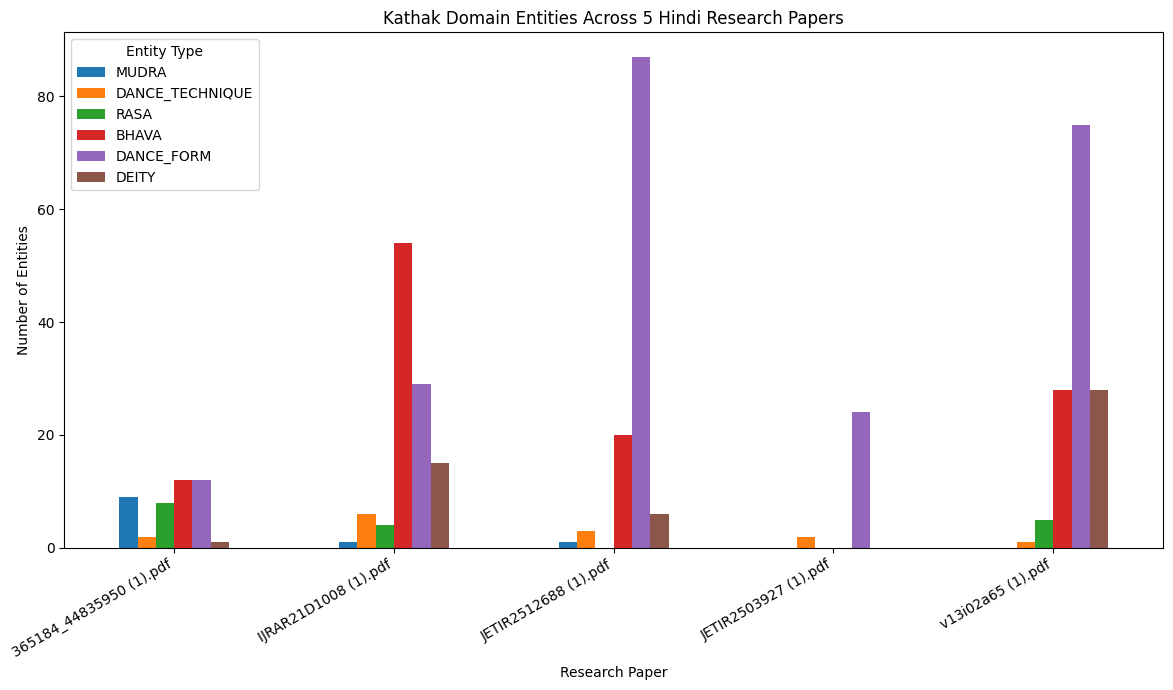

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

counts = {}

for f, entities in all_domain_entities.items():
    counts[f] = Counter(
        e["label"] for e in entities
        if e is not None and "label" in e
    )

df = pd.DataFrame.from_dict(counts, orient="index").fillna(0)

print(df)

df.plot(kind="bar", figsize=(12,7))

plt.title("Kathak Domain Entities Across 5 Hindi Research Papers")
plt.xlabel("Research Paper")
plt.ylabel("Number of Entities")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Entity Type")
plt.tight_layout()
plt.show()

In [69]:
from IPython.display import display, HTML
from html import escape

colors = {
    "MUDRA": "#FFB74D",
    "DANCE_FORM": "#CE93D8",
    "DANCE_TECHNIQUE": "#80CBC4",
    "BHAVA": "#F48FB1",
    "RASA": "#FFCC80",
    "DEITY": "#B39DDB"
}

for f, text in documents.items():
    html, pos = "", 0

    entities = sorted(
        all_domain_entities[f],
        key=lambda x: x["start"]
    )

    for e in entities:
        if e["start"] < pos:
            continue

        html += escape(text[pos:e["start"]])

        html += (
            f'<mark style="background:{colors[e["label"]]}'
            f';padding:3px 6px;border-radius:5px">'
            f'<b>{escape(e["word"])}</b> '
            f'<small>[{e["label"]}]</small></mark>'
        )

        pos = e["end"]

    html += escape(text[pos:])

    display(HTML(f"""
    <h2>{escape(f)}</h2>
    <div style="font-size:16px;line-height:2.2">
        {html}
    </div>
    <hr>
    """))

In [78]:
from IPython.display import display, HTML
from html import escape

# -------------------------------------------------
# COLORS
# -------------------------------------------------

entity_colors = {
    "PER": "#64B5F6",
    "LOC": "#FFD54F",
    "ORG": "#424242",

    "DANCE_FORM": "#AB78D1",
    "MUDRA": "#FF9800",
    "DANCE_TECHNIQUE": "#80CBC4",
    "BHAVA": "#F48FB1",
    "RASA": "#FFCC80",
    "DEITY": "#9575CD",
    "LITERARY_WORK": "#A1887F"
}

entity_names = {
    "PER": "Person",
    "LOC": "Location",
    "ORG": "Organization",

    "DANCE_FORM": "Dance Form",
    "MUDRA": "Mudra",
    "DANCE_TECHNIQUE": "Dance Technique",
    "BHAVA": "Bhava",
    "RASA": "Rasa",
    "DEITY": "Deity",
    "LITERARY_WORK": "Literary Work"
}

# -------------------------------------------------
# PROCESS ALL 5 PAPERS
# -------------------------------------------------

for paper in pdf_files:

    text = documents[paper]

    entities = all_domain_entities.get(paper, [])

    # Remove invalid entities
    entities = [
        e for e in entities
        if e is not None
        and e.get("word", "").strip()
        and "start" in e
        and "end" in e
        and "label" in e
    ]

    # Sort by location in original text
    entities = sorted(
        entities,
        key=lambda e: (e["start"], -(e["end"] - e["start"]))
    )

    # -------------------------------------------------
    # CREATE COLORED TEXT
    # -------------------------------------------------

    highlighted_text = ""
    position = 0

    for e in entities:

        start = e["start"]
        end = e["end"]
        word = e["word"]
        label = e["label"]

        # Ignore overlapping entities
        if start < position:
            continue

        # Normal text
        highlighted_text += escape(text[position:start])

        # Entity color
        color = entity_colors.get(label, "#CCCCCC")

        # Entity box
        highlighted_text += f"""
        <span style="
            background:{color};
            color:#111;
            padding:4px 7px;
            margin:2px;
            border-radius:5px;
            font-weight:bold;
            display:inline-block;
        ">
            {escape(word)}
            <small style="font-weight:bold;">
                {escape(label)}
            </small>
        </span>
        """

        position = end

    # Remaining text
    highlighted_text += escape(text[position:])

    # -------------------------------------------------
    # CREATE LEGEND
    # -------------------------------------------------

    legend_html = ""

    # Only show labels actually present in this paper
    labels_present = []

    for e in entities:
        if e["label"] not in labels_present:
            labels_present.append(e["label"])

    for label in labels_present:

        color = entity_colors.get(label, "#CCCCCC")
        name = entity_names.get(label, label)

        legend_html += f"""
        <span style="
            display:inline-flex;
            margin:4px;
            border-radius:5px;
            overflow:hidden;
            font-family:Arial,sans-serif;
            font-weight:bold;
        ">

            <span style="
                background:{color};
                color:white;
                padding:7px 11px;
            ">
                {name}
            </span>

            <span style="
                background:white;
                color:#222;
                padding:7px 9px;
                border:1px solid #ddd;
            ">
                {label}
            </span>

        </span>
        """

    # -------------------------------------------------
    # ONE COMBINED OUTPUT
    # -------------------------------------------------

    display(HTML(f"""

    <div style="
        margin:25px 0 40px 0;
        border:1px solid #d0d0d0;
        border-radius:10px;
        overflow:hidden;
        background:white;
    ">

        <!-- PAPER TITLE -->
        <div style="
            background:#4169E1;
            color:white;
            padding:12px 18px;
            font-size:20px;
            font-weight:bold;
        ">
            {escape(paper)}
        </div>

        <!-- LEGEND -->
        <div style="
            background:#4169E1;
            padding:12px 18px;
            border-top:1px solid rgba(255,255,255,0.3);
        ">
            {legend_html}
        </div>

        <!-- PAPER TEXT -->
        <div style="
            font-family:
                'Noto Sans Devanagari',
                'Arial Unicode MS',
                sans-serif;

            font-size:16px;
            line-height:2.2;

            padding:22px;

            color:#222;
            background:white;

            white-space:normal;
        ">
            {highlighted_text}
        </div>

    </div>

    """))